In [ ]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler,LabelEncoder,MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,roc_auc_score,roc_curve

In [ ]:
#load datset
dataset=pd.read_csv('/content/framingham.csv')

In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4238 entries, 0 to 4237
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4238 non-null   int64  
 1   age              4238 non-null   int64  
 2   education        4133 non-null   float64
 3   currentSmoker    4238 non-null   int64  
 4   cigsPerDay       4209 non-null   float64
 5   BPMeds           4185 non-null   float64
 6   prevalentStroke  4238 non-null   int64  
 7   prevalentHyp     4238 non-null   int64  
 8   diabetes         4238 non-null   int64  
 9   totChol          4188 non-null   float64
 10  sysBP            4238 non-null   float64
 11  diaBP            4238 non-null   float64
 12  BMI              4219 non-null   float64
 13  heartRate        4237 non-null   float64
 14  glucose          3850 non-null   float64
 15  TenYearCHD       4238 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 529.9 KB


In [ ]:
dataset.describe()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,4238.000000,4238.000000,4133.000000,4238.000000,4209.000000,4185.000000,4238.000000,4238.000000,4238.000000,4188.000000,4238.000000,4238.000000,4219.000000,4237.000000,3850.000000,4238.000000
mean,0.429212,49.584946,1.978950,0.494101,9.003089,0.029630,0.005899,0.310524,0.025720,236.721585,132.352407,82.893464,25.802008,75.878924,81.966753,0.151958
std,0.495022,8.572160,1.019791,0.500024,11.920094,0.169584,0.076587,0.462763,0.158316,44.590334,22.038097,11.910850,4.080111,12.026596,23.959998,0.359023
min,0.000000,32.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,107.000000,83.500000,48.000000,15.540000,44.000000,40.000000,0.000000
25%,0.000000,42.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.000000,75.000000,23.070000,68.000000,71.000000,0.000000
50%,0.000000,49.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.000000,82.000000,25.400000,75.000000,78.000000,0.000000
75%,1.000000,56.000000,3.000000,1.000000,20.000000,0.000000,0.000000,1.000000,0.000000,263.000000,144.000000,89.875000,28.040000,83.000000,87.000000,0.000000
max,1.000000,70.000000,4.000000,1.000000,70.000000,1.000000,1.000000,1.000000,1.000000,696.000000,295.000000,142.500000,56.800000,143.000000,394.000000,1.000000


In [ ]:
dataset.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [ ]:
dataset.shape

(4238, 16)

In [ ]:
dataset.isnull().sum()

,0
male,0
age,0
education,105
currentSmoker,0
cigsPerDay,29
BPMeds,53
prevalentStroke,0
prevalentHyp,0
diabetes,0
totChol,50


In [ ]:
# Check duplicate records
print("Number of duplicate rows:", dataset.duplicated().sum())

Number of duplicate rows: 0


In [ ]:
#fill the missing values
dataset['glucose'].fillna(dataset['glucose'].mean(),inplace=True)
dataset['heartRate'].fillna(dataset['heartRate'].mean(),inplace=True)
dataset['BMI'].fillna(dataset['BMI'].mean(),inplace=True)
dataset['cigsPerDay'].fillna(dataset['cigsPerDay'].mean(),inplace=True)


/tmp/ipykernel_1227/2446072348.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['glucose'].fillna(dataset['glucose'].mean(),inplace=True)
/tmp/ipykernel_1227/2446072348.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inp

In [ ]:
print(dataset.isnull().sum())

male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay           0
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                  0
heartRate            0
glucose              0
TenYearCHD           0
dtype: int64


In [ ]:
if 'education' in dataset.columns:
    dataset.drop('education', axis=1, inplace=True)
    print("Column 'education' dropped successfully.")
else:
    print("Column 'education' not found. It might have been dropped already.")

Column 'education' dropped successfully.


In [ ]:
print(dataset.isnull().sum())

male                0
age                 0
currentSmoker       0
cigsPerDay          0
BPMeds             53
prevalentStroke     0
prevalentHyp        0
diabetes            0
totChol            50
sysBP               0
diaBP               0
BMI                 0
heartRate           0
glucose             0
TenYearCHD          0
dtype: int64


In [ ]:
dataset['BPMeds'].fillna(dataset['BPMeds'].mean(),inplace=True)
dataset['totChol'].fillna(dataset['totChol'].mean(),inplace=True)

/tmp/ipykernel_1227/139219027.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['BPMeds'].fillna(dataset['BPMeds'].mean(),inplace=True)
/tmp/ipykernel_1227/139219027.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace

In [ ]:
print(dataset.isnull().sum())

male               0
age                0
currentSmoker      0
cigsPerDay         0
BPMeds             0
prevalentStroke    0
prevalentHyp       0
diabetes           0
totChol            0
sysBP              0
diaBP              0
BMI                0
heartRate          0
glucose            0
TenYearCHD         0
dtype: int64


In [ ]:
# Display first five rows
print(dataset.head())

   male  age  currentSmoker  cigsPerDay  BPMeds  prevalentStroke  \
0     1   39              0         0.0     0.0                0   
1     0   46              0         0.0     0.0                0   
2     1   48              1        20.0     0.0                0   
3     0   61              1        30.0     0.0                0   
4     0   46              1        23.0     0.0                0   

   prevalentHyp  diabetes  totChol  sysBP  diaBP    BMI  heartRate  glucose  \
0             0         0    195.0  106.0   70.0  26.97       80.0     77.0   
1             0         0    250.0  121.0   81.0  28.73       95.0     76.0   
2             0         0    245.0  127.5   80.0  25.34       75.0     70.0   
3             1         0    225.0  150.0   95.0  28.58       65.0    103.0   
4             0         0    285.0  130.0   84.0  23.10       85.0     85.0   

   TenYearCHD  
0           0  
1           0  
2           0  
3           1  
4           0  


In [ ]:
dataset['Cardio_Risk_Score'] = (dataset['currentSmoker'] +dataset['BPMeds'])
print("Cardio_Risk_Score feature created:")
display(dataset[['currentSmoker','BPMeds']].head())

Cardio_Risk_Score feature created:


,currentSmoker,BPMeds
0,0,0.0
1,0,0.0
2,1,0.0
3,1,0.0
4,1,0.0


In [ ]:
dataset['High_Blood_Pressure_Risk'] = ((dataset['sysBP'] >= 140) | (dataset['diaBP'] >= 90)).astype(int)
print("High_Blood_Pressure_Risk feature created:")
display(dataset[['sysBP', 'diaBP', 'High_Blood_Pressure_Risk']].head())

High_Blood_Pressure_Risk feature created:


,sysBP,diaBP,High_Blood_Pressure_Risk
0,106.0,70.0,0
1,121.0,81.0,0
2,127.5,80.0,0
3,150.0,95.0,1
4,130.0,84.0,0


In [ ]:
# add 'Cardio_Risk_Score' and 'High_Blood_Pressure_Risk' features to the dataset
dataset['Cardio_Risk_Score'] = (dataset['currentSmoker'] + dataset['BPMeds'])
dataset['High_Blood_Pressure_Risk'] = ((dataset['sysBP'] >= 140) | (dataset['diaBP'] >= 90)).astype(int)
display(dataset[['Cardio_Risk_Score','High_Blood_Pressure_Risk']].head())

,Cardio_Risk_Score,High_Blood_Pressure_Risk
0,0.0,0
1,0.0,0
2,1.0,0
3,1.0,1
4,1.0,0


In [ ]:
#outlier detection
Q1=dataset['sysBP'].quantile(0.25)
Q3=dataset['sysBP'].quantile(0.75)
IQR=Q3-Q1
print(IQR)
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
print(lower_bound)
print(upper_bound)

27.0
76.5
184.5


In [ ]:
#print(outliers)
outliers=dataset[(dataset['sysBP']<lower_bound) | (dataset['sysBP']>upper_bound)]
print(outliers)

      male  age  currentSmoker  cigsPerDay  BPMeds  prevalentStroke  \
44       0   53              0         0.0     1.0                0   
66       0   62              0         0.0     0.0                0   
87       0   61              1         1.0     0.0                0   
108      0   66              0         0.0     0.0                0   
153      0   66              0         0.0     0.0                0   
...    ...  ...            ...         ...     ...              ...   
4123     1   51              0         0.0     0.0                0   
4173     0   54              0         0.0     0.0                0   
4193     0   63              0         0.0     0.0                0   
4222     1   53              0         0.0     0.0                0   
4228     0   50              0         0.0     0.0                0   

      prevalentHyp  diabetes  totChol  sysBP  diaBP    BMI  heartRate  \
44               1         1    311.0  206.0   92.0  21.51       76.0   
6

In [ ]:
# remove outliers
dataset=dataset[(dataset['sysBP']>=lower_bound) & (dataset['sysBP']<=upper_bound)]
print(dataset.shape)

(4112, 17)


In [ ]:
# outlier detcetion for glucose
Q1=dataset['glucose'].quantile(0.25)
Q3=dataset['glucose'].quantile(0.75)
IQR=Q3-Q1
print(IQR)
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
print(lower_bound)
print(upper_bound)

13.0
52.5
104.5


In [ ]:
# remove outliers
dataset=dataset[(dataset['glucose']>=lower_bound) & (dataset['glucose']<=upper_bound)]
print(dataset.shape)

(3871, 17)


In [ ]:
# Identify Feature and target variable
x = dataset.drop('TenYearCHD', axis=1)
y = dataset['TenYearCHD']

In [ ]:
# Split the dataset into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=123)

In [ ]:
print(f"Number of instances for training: {len(x_train)}")
print(f"Number of instances for testing: {len(x_test)}")

Number of instances for training: 3096
Number of instances for testing: 775


In [ ]:
scaler=StandardScaler()
cols_to_scaler=['sysBP','currentSmoker','BPMeds','Cardio_Risk_Score']
x_train[cols_to_scaler]=scaler.fit_transform(x_train[cols_to_scaler])
x_test[cols_to_scaler]=scaler.transform(x_test[cols_to_scaler])
print("First 5 rows",x_train.head())

First 5 rows       male  age  currentSmoker  cigsPerDay    BPMeds  prevalentStroke  \
2408     0   44       1.001293         3.0 -0.154562                0   
4110     1   45      -0.998709         0.0 -0.154562                0   
1991     1   57      -0.998709         0.0 -0.154562                0   
2059     1   40       1.001293         3.0 -0.154562                0   
1639     0   54       1.001293         5.0 -0.154562                0   

      prevalentHyp  diabetes  totChol     sysBP  diaBP    BMI  heartRate  \
2408             0         0    288.0  1.097145   89.0  21.11       90.0   
4110             0         0    220.0  0.503235   74.0  27.34       70.0   
1991             0         0    198.0 -0.576602   80.0  30.05       70.0   
2059             0         0    165.0 -0.684586   77.0  21.71       50.0   
1639             1         0    298.0  1.178133   96.5  30.29       64.0   

      glucose  Cardio_Risk_Score  High_Blood_Pressure_Risk  
2408     97.0           0.9256

In [ ]:
#Model Building
model=LogisticRegression()
model.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
#predictions on test_data
y_pred=model.predict(x_test)

In [ ]:
train_accuracy=accuracy_score(y_train,model.predict(x_train))
test_accuracy=accuracy_score(y_test,y_pred)
print("Train Accuracy:",train_accuracy)
print("Test Accuracy:",test_accuracy)

Train Accuracy: 0.8591731266149871
Test Accuracy: 0.8606451612903225


In [ ]:
# confusion matrix
conf_matrix=confusion_matrix(y_test,y_pred)
print("Confusion Matrix:")
print(conf_matrix)

Confusion Matrix:
[[666   6]
 [102   1]]


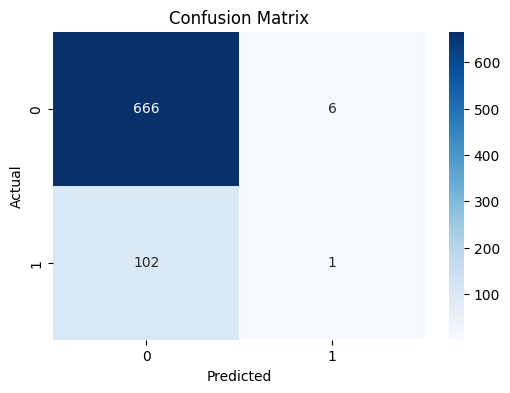

In [ ]:
# display confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(conf_matrix,annot=True,fmt='d',cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# print classification report
class_report=classification_report(y_test,y_pred)
print("Classification Report:")
print(class_report)

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.99      0.93       672
           1       0.14      0.01      0.02       103

    accuracy                           0.86       775
   macro avg       0.51      0.50      0.47       775
weighted avg       0.77      0.86      0.80       775



In [ ]:
# roc_auc_score
fpr,tpr,thresholds=roc_curve(y_test,y_pred)
roc_auc=roc_auc_score(y_test,y_pred)
print("ROC AUC Score:",roc_auc)

ROC AUC Score: 0.5003900832177531


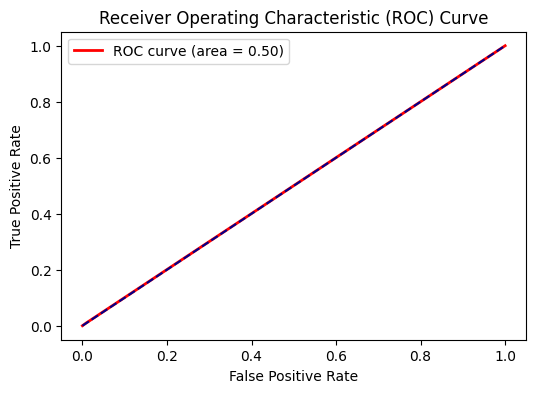

In [ ]:
# display auc_roc_curve
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, color='red', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0,1],[0,1],color='darkblue',linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()